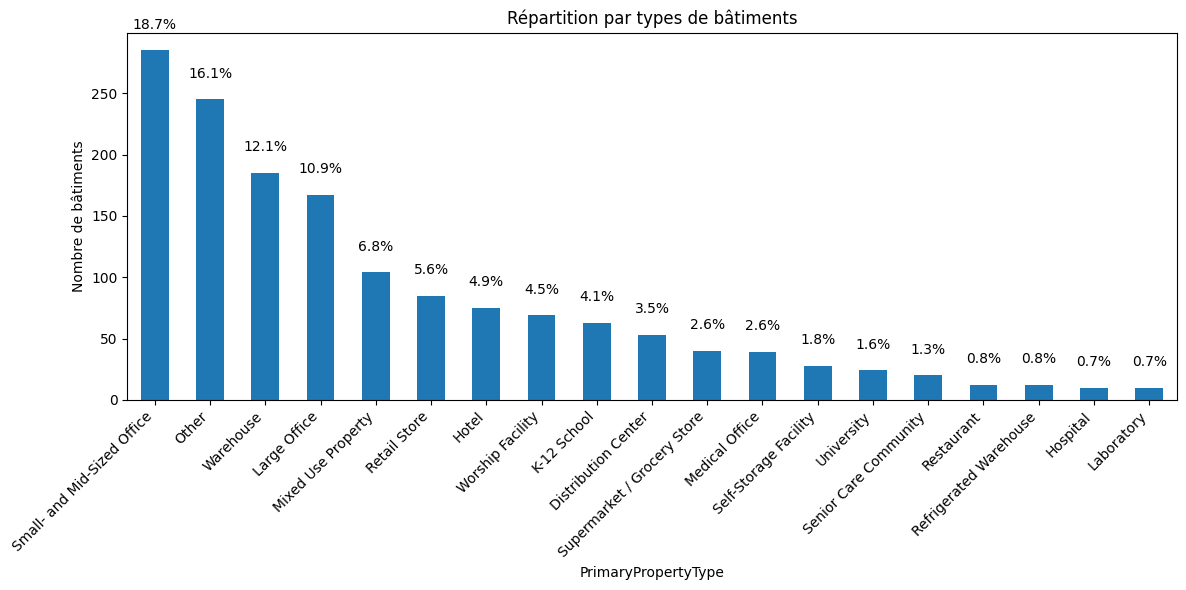

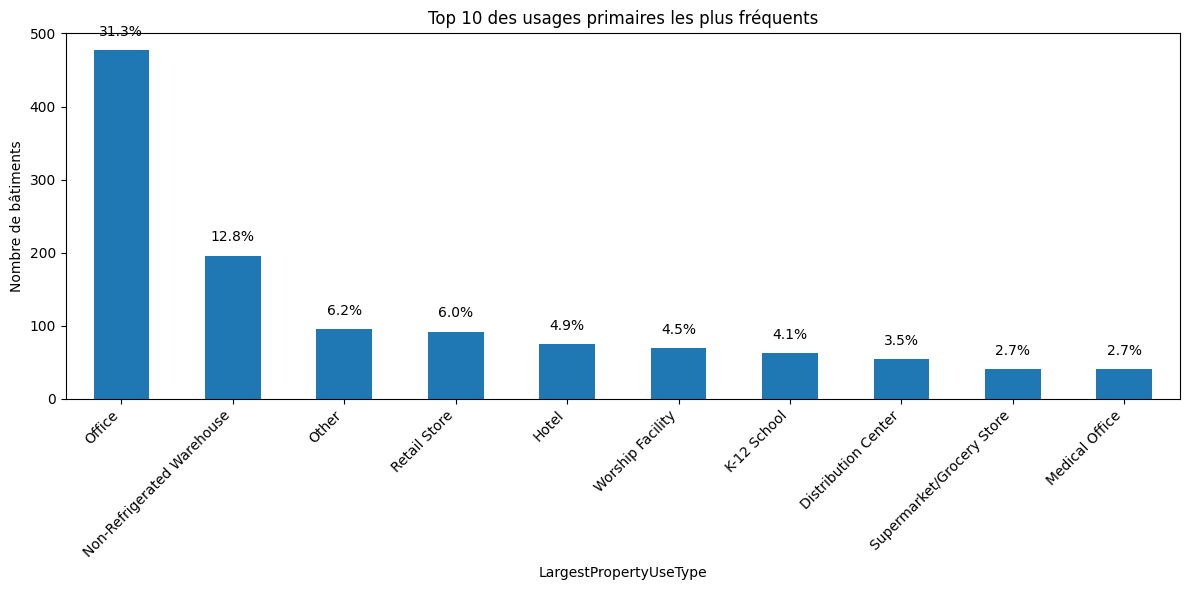

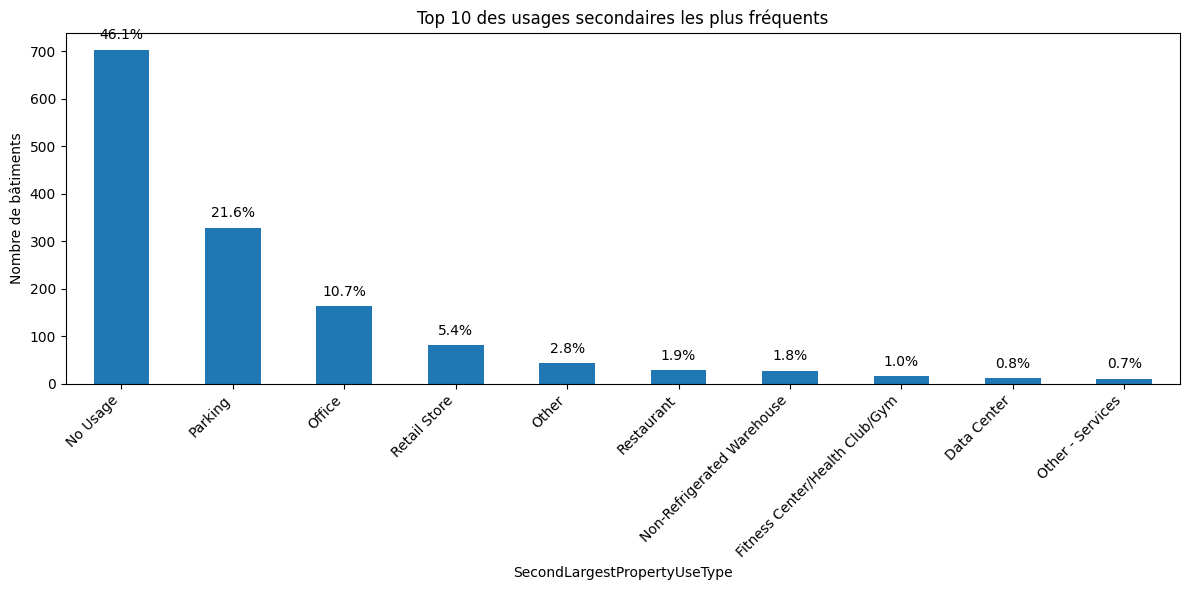

In [1]:
# On exécute le précédent notebook car on est dépendant des résultats
import sys
import os
from contextlib import redirect_stdout, redirect_stderr

with open(os.devnull, 'w') as fnull:
    with redirect_stdout(fnull), redirect_stderr(fnull):
        %run 1_analyse-exploratoire.ipynb


In [2]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
import numpy as np
scaler = MinMaxScaler()


# Feature Engineering

## Besoins en données
On a besoin à minima des données suivantes : 

* Surface totale
* Localisation
* Usage du bâtiment
* Nombre de bâtiments et / ou d'étages (surface exposée à l'air)
* Année de construction
  
## Features

### Surface totale
  * `PropertyGFATotal` : on utilise MinMaxScaler pour diminuer la grande amplitude des données


In [3]:
df['PropertyGFATotalScaled'] = scaler.fit_transform(df[['PropertyGFATotal']])

### Localisation
  * `Neighborhood` : information pertinente en terme de localisation, car elle peut englober un facteur d'architecture d'urbanisme qui fera potentiellement varier les résultats (exemple : dépendance de tout un quartier à une infrastructure électrique comme un ou plusieurs transformateurs). On utilise un **OneHotEncoder** car il s'agit d'une catégorie non ordinale



In [4]:
# Appliquer le One-Hot Encoding sur Neighborhood, d'après l'analyse précédente on va limiter à 12 le nombre de catégories
encoder = OneHotEncoder(sparse_output=False, max_categories=12)
neighborhood_encoded = encoder.fit_transform(df[['Neighborhood']])

# Ajouter les colonnes encodées directement au DataFrame
df = pd.concat([df.drop('Neighborhood', axis=1),
                pd.DataFrame(neighborhood_encoded,
                           columns=encoder.get_feature_names_out(['Neighborhood']),
                           index=df.index)], axis=1)

# Vérification
neighborhood_columns = [col for col in df.columns if col.startswith('Neighborhood_')]
print(f"Nombre de nouvelles colonnes Neighborhood_ créées : {len(neighborhood_columns)}")

Nombre de nouvelles colonnes Neighborhood_ créées : 12



  * `Lat` / `Lng` : ces données de localisation sont très fines mais le modèle ne comprendra naturellement pas l'aspect géographique. On va grouper les données (clusters) afin de capter des effets locaux / zones caractéristiques.

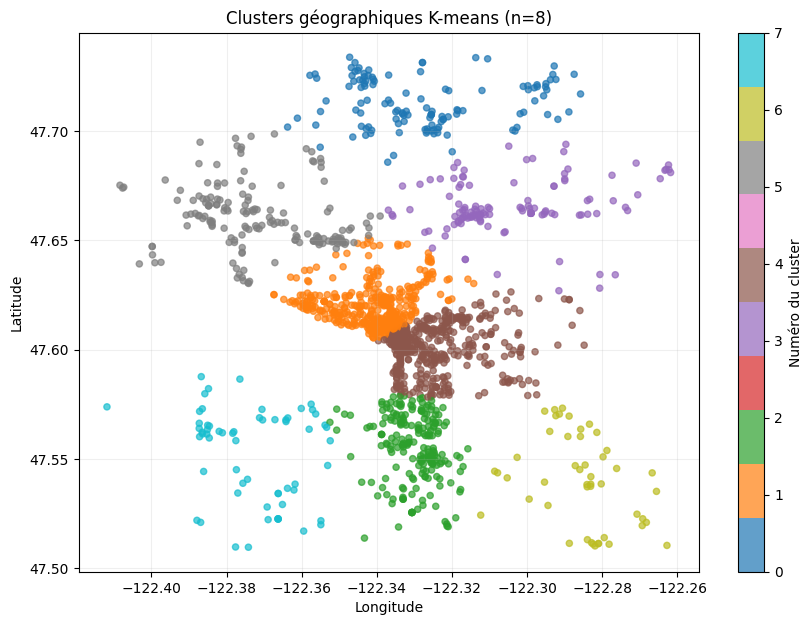

In [5]:
# Appliquer le K-means sur Lat & Lng
n_clusters = 8 # à ajuster selon la taille de la ville
coords = df[['Latitude', 'Longitude']]
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
df['GeoCluster'] = kmeans.fit_predict(coords)

# Affichage des clusters sur une carte scatter
plt.figure(figsize=(10, 7))
scatter = plt.scatter(df['Longitude'], df['Latitude'], c=df['GeoCluster'], cmap='tab10', s=20, alpha=0.7)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Clusters géographiques K-means (n='+str(n_clusters)+')')
cbar = plt.colorbar(scatter, ticks=range(n_clusters))
cbar.set_label('Numéro du cluster')
plt.grid(True, alpha=0.2)
plt.show()


### Usage du bâtiment

* `PrimaryPropertyType` est l'usage principal du bâtiment, cette variable est critique pour mesurer la consommation. On ne peut pas l'utiliser telle quelle, on va appliquer un OneHot Encoding.

In [6]:
# Appliquer le one-hot encoding sur PrimaryPropertyType
df = pd.get_dummies(df, columns=['PrimaryPropertyType'], prefix='Type')

# Vérifier le résultat
print(f"Nombre de colonnes d'usage primaire créées : {len([col for col in df.columns if col.startswith('Type_')])}")

Nombre de colonnes d'usage primaire créées : 19


* On crée une feature pour savoir si un bâtiment a **plusieurs** usages.

In [7]:
df['MultipleUsages'] = df['ListOfAllPropertyUseTypes'].str.contains(',', na=False)

### Nombre de bâtiments et / ou d'étages (surface exposée à l'air)

* Nombre de bâtiments `NumberofBuildings` : on constate qu'il y a quelques données outlier, notamment le `University of Washington - Seattle Campus` qui a une donnée extrême de **111** bâtiments. On fait le choix de garder cette donnée car elle est vérifiée, toutefois on pourra agir dessus si besoin selon les performances du modèle

In [8]:
# décommenter pour décrire et voir les outliers
# print(df[['NumberofFloors', 'NumberofBuildings']].describe())
# display((df['NumberofBuildings'] > 12).sum())

* Nombre d'étages `NumberofFloors` : on constate un outlier qui est une erreur : `Seattle Chinese Baptist Church` est notée comme ayant 99 étages, en réalité l'église semble n'avoir que 2 étages (vérifié sur le net). On corrige donc cette valeur abbérante.

In [9]:
# décommenter pour voir les bâtiments qui ont plus de 40 étages
# display(df[df['NumberofFloors'] > 40])

# correction du nombre d'étages pour l'église Chinese Baptiste
df.loc[df['OSEBuildingID'] == 21611, 'NumberofFloors'] = 2

### Année de construction

L'année de construction nous permet de déduire des consommations en énergie / C02 à partir de l'âge d'un bâtiment.
On va se servir de cette donnée pour créer une nouvelle feature `BuildingAge` **calculée à partir de la date de collecte des données**

**Attention : Bien que l'âge peut être très pertinent pour la prédiction, il va également entrainer du drift du modèle. Il faudra donc régulièrement réentrainer notre modèle si l'on utilise cette feature** 


=== ANALYSE DE LA VARIABLE YearBuilt ===
Nombre total de bâtiments: 1526
Valeurs manquantes: 0
Année minimum: 1900
Année maximum: 2015
Médiane: 1966.0


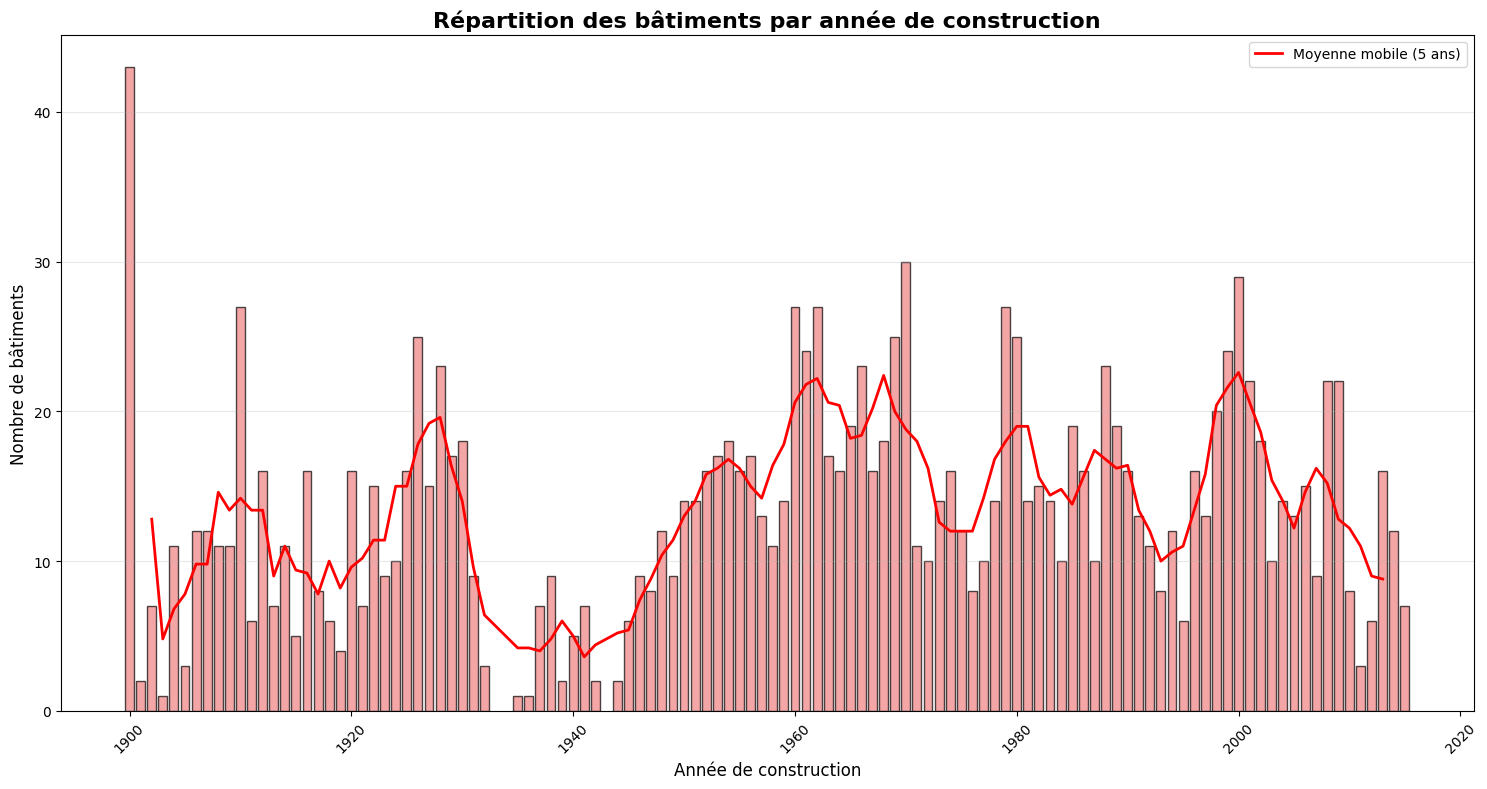

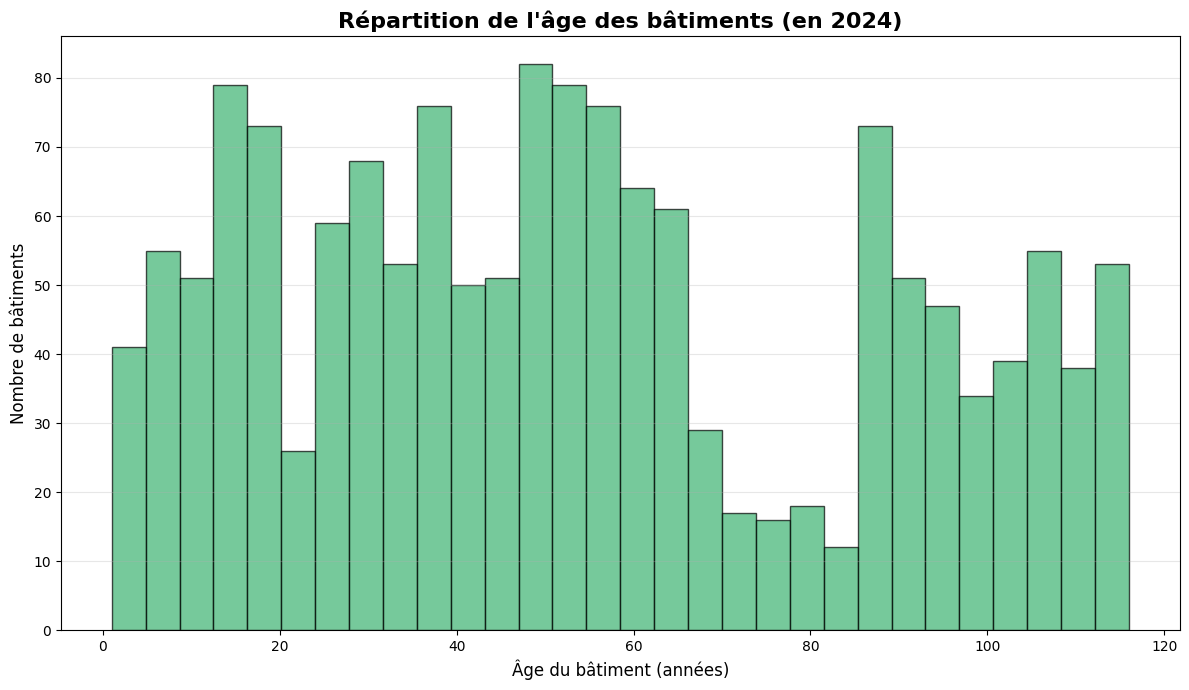

In [10]:
print("=== ANALYSE DE LA VARIABLE YearBuilt ===")
print(f"Nombre total de bâtiments: {len(df)}")
print(f"Valeurs manquantes: {df['YearBuilt'].isna().sum()}")
print(f"Année minimum: {df['YearBuilt'].min()}")
print(f"Année maximum: {df['YearBuilt'].max()}")
print(f"Médiane: {df['YearBuilt'].median()}")

# Compter le nombre de bâtiments par année
year_counts = df['YearBuilt'].value_counts().sort_index()

# Créer l'histogramme
plt.figure(figsize=(15, 8))
bars = plt.bar(year_counts.index, year_counts.values, color='lightcoral', alpha=0.7, edgecolor='black', width=0.8)
plt.title('Répartition des bâtiments par année de construction', fontsize=16, fontweight='bold')
plt.ylabel('Nombre de bâtiments', fontsize=12)
plt.xlabel('Année de construction', fontsize=12)
plt.grid(axis='y', alpha=0.3)

# Rotation des labels pour une meilleure lisibilité
plt.xticks(rotation=45)

# Ajouter une ligne de tendance (moyenne mobile)
window = 5
if len(year_counts) >= window:
    moving_avg = year_counts.rolling(window=window, center=True).mean()
    plt.plot(moving_avg.index, moving_avg.values, color='red', linewidth=2, label=f'Moyenne mobile ({window} ans)')
    plt.legend()

plt.tight_layout()
plt.show()

# Calculer l'âge du bâtiment
df['BuildingAge'] = df['DataYear'] - df['YearBuilt']

# Histogramme de l'âge
plt.figure(figsize=(12, 7))
plt.hist(df['BuildingAge'], bins=30, color='mediumseagreen', edgecolor='black', alpha=0.7)
plt.title("Répartition de l'âge des bâtiments (en 2024)", fontsize=16, fontweight='bold')
plt.xlabel("Âge du bâtiment (années)", fontsize=12)
plt.ylabel("Nombre de bâtiments", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()